[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/05_fitting_models.ipynb)

# 5. Fitting models to data

**What you should get out of this notebook**

- See why least squares is the maximum likelihood method for normally distributed errors.
- Fit a straight line and, more generally, any model with `curve_fit`, and obtain uncertainties on the parameters from the covariance matrix.
- Judge a fit by its residuals and its chi-squared value, with the right number of degrees of freedom.
- Understand joint confidence regions for several parameters, and the $\Delta\chi^2$ rule.
- Apply maximum likelihood outside least squares, to estimate the Gutenberg–Richter $b$-value.

**Tools introduced**

- `np.polyfit`, `stats.linregress`
- `scipy.optimize.curve_fit` with `sigma=` and `absolute_sigma=True`
- `stats.chi2` for goodness of fit and for $\Delta\chi^2$ thresholds
- `scipy.stats` `.fit` methods with fixed parameters (`floc`)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

In [ ]:
from scipy.optimize import curve_fit

## From likelihood to least squares

We have data $(x_i, y_i)$, $i = 1, \dots, n$, and a model $y = f(x; \boldsymbol{\theta})$ with parameters $\boldsymbol{\theta}$ that we wish to determine. As in Notebook 4, assume the $x_i$ are known exactly and the $y_i$ have independent normal errors with standard deviations $\sigma_i$. Then the probability density of observing the data, for given parameters, is

$$
L(\boldsymbol{\theta}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\,\sigma_i}
\exp\!\left[-\frac{\big(y_i - f(x_i; \boldsymbol{\theta})\big)^2}{2\sigma_i^2}\right].
$$

Regarded as a function of the parameters, this is the **likelihood**. The **maximum likelihood** principle says to choose the parameters that make the observed data most probable. Taking the logarithm,

$$
-\ln L(\boldsymbol{\theta}) = \tfrac{1}{2}\chi^2(\boldsymbol{\theta}) + \text{const}, \qquad
\chi^2(\boldsymbol{\theta}) = \sum_{i=1}^{n} \frac{\big(y_i - f(x_i; \boldsymbol{\theta})\big)^2}{\sigma_i^2},
$$

so maximising the likelihood is the same as minimising $\chi^2$: this is **weighted least squares**. If all the $\sigma_i$ are equal it reduces to ordinary least squares, minimising the sum of squared residuals. Least squares is therefore not an arbitrary choice: it is what maximum likelihood gives for normal errors. For other error distributions (Poisson counts, say, or heavy-tailed errors) maximum likelihood gives a different, and better, criterion.

## The straight line

For $f(x; a, b) = a x + b$ with equal errors, setting the derivatives of $\chi^2$ with respect to $a$ and $b$ to zero gives the familiar formulae

$$
\hat{a} = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2}, \qquad
\hat{b} = \bar{y} - \hat{a}\,\bar{x},
$$

where $\bar{x}$ and $\bar{y}$ are the sample means. Let us generate data as in Notebook 4 and fit them by hand and with three library routines.

In [ ]:
n = 50
x = np.linspace(0, 1, n)
sigma = 0.2
a_true, b_true = 2.0, -4.0
y = a_true*x + b_true + stats.norm(0, sigma).rvs(n, random_state=rng)

# by hand
a_hat = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean())**2)
b_hat = y.mean() - a_hat * x.mean()
print(f"by hand:     a = {a_hat:.4f}, b = {b_hat:.4f}")

# numpy.polyfit (degree 1)
print(f"polyfit:     a = {np.polyfit(x, y, 1)[0]:.4f}, b = {np.polyfit(x, y, 1)[1]:.4f}")

# scipy.stats.linregress
lr = stats.linregress(x, y)
print(f"linregress:  a = {lr.slope:.4f}, b = {lr.intercept:.4f}")

# scipy.optimize.curve_fit, the general tool
line = lambda x, a, b: a*x + b
popt, pcov = curve_fit(line, x, y, sigma=np.full(n, sigma), absolute_sigma=True)
print(f"curve_fit:   a = {popt[0]:.4f}, b = {popt[1]:.4f}")

by hand:     a = 1.9513, b = -3.9829
polyfit:     a = 1.9513, b = -3.9829
linregress:  a = 1.9513, b = -3.9829
curve_fit:   a = 1.9513, b = -3.9829


All four agree, as they must. `curve_fit` is the one to learn: it fits *any* function you can write in Python, takes per-point uncertainties through `sigma=`, and returns the covariance matrix of the fitted parameters. The flag `absolute_sigma=True` tells it that the uncertainties are real standard deviations, to be used as they stand. Without it, `curve_fit` treats `sigma` as relative weights only and rescales the covariance so that the reduced chi-squared is 1, which is appropriate when the errors are *unknown*; more on this below.

## Uncertainties on the parameters

The fitted parameters are functions of the noisy data and so are random variables, just like the sample mean in Notebook 2. For a model that is linear in its parameters, $f = \sum_k \theta_k A_k(x)$, the fitted parameters are linear combinations of the $y_i$ and their covariance matrix follows exactly from the rules of Notebook 3:

$$
\mathbf{C}_{\theta} = \big(\mathbf{A}^T \mathbf{W} \mathbf{A}\big)^{-1},
\qquad A_{ik} = A_k(x_i), \quad \mathbf{W} = \mathrm{diag}(1/\sigma_i^2).
$$

The standard errors of the parameters are the square roots of the diagonal entries; the off-diagonal entries give the correlation between parameters. For the straight line, slope and intercept are negatively correlated whenever the $x_i$ are positive: tilting the line up forces the intercept down. `curve_fit` returns $\mathbf{C}_\theta$ as `pcov`. For nonlinear models the same expression holds approximately, with $\mathbf{A}$ replaced by the matrix of partial derivatives of $f$ at the solution, which is the linearisation of Notebook 3 once again.

Let us look at `pcov` and then check it by brute force: generate many synthetic data sets, fit each, and compare the scatter of the fitted parameters with what the covariance matrix predicts.

a = 1.951 ± 0.096,  b = -3.983 ± 0.056
correlation between a and b: -0.862

scatter of fitted a over 2000 simulations: 0.095   (predicted 0.096)
scatter of fitted b over 2000 simulations: 0.055   (predicted 0.056)
correlation from simulations:              -0.864


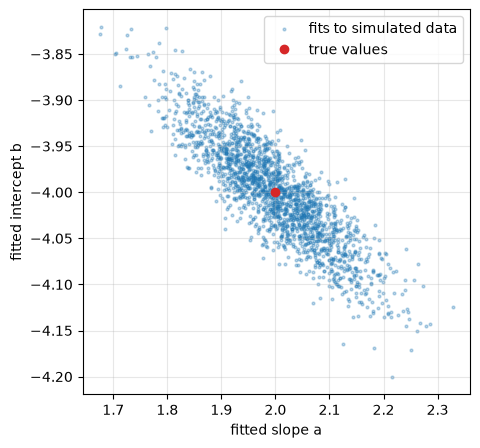

In [ ]:
sa, sb = np.sqrt(np.diag(pcov))
print(f"a = {popt[0]:.3f} ± {sa:.3f},  b = {popt[1]:.3f} ± {sb:.3f}")
print(f"correlation between a and b: {pcov[0, 1] / (sa * sb):.3f}")

# Brute-force check: refit many synthetic data sets
fits = []
for _ in range(2000):
    y_sim = a_true*x + b_true + stats.norm(0, sigma).rvs(n, random_state=rng)
    fits.append(np.polyfit(x, y_sim, 1))
fits = np.array(fits)
print(f"\nscatter of fitted a over 2000 simulations: {fits[:, 0].std():.3f}   (predicted {sa:.3f})")
print(f"scatter of fitted b over 2000 simulations: {fits[:, 1].std():.3f}   (predicted {sb:.3f})")
print(f"correlation from simulations:              {np.corrcoef(fits[:, 0], fits[:, 1])[0, 1]:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(fits[:, 0], fits[:, 1], s=4, alpha=0.3, label="fits to simulated data")
ax.plot(a_true, b_true, "C3o", label="true values")
ax.set(xlabel="fitted slope a", ylabel="fitted intercept b"); ax.legend()
plt.show()

The covariance matrix predicts the scatter of repeated fits correctly, and the tilted ellipse of points is the negative correlation.

## Is the fit any good?

A least-squares routine will happily fit a straight line to a parabola. Whether the model is *adequate* is a separate question, answered by the chi-squared test of Notebook 4 with one change: because two parameters have been adjusted to fit the data, the residuals have only $\nu = n - 2$ degrees of freedom. In general $\nu = n - p$ for $p$ fitted parameters. And, always, look at the residuals.

χ² = 38.6,  ν = 48,  reduced χ² = 0.80,  p = 0.833


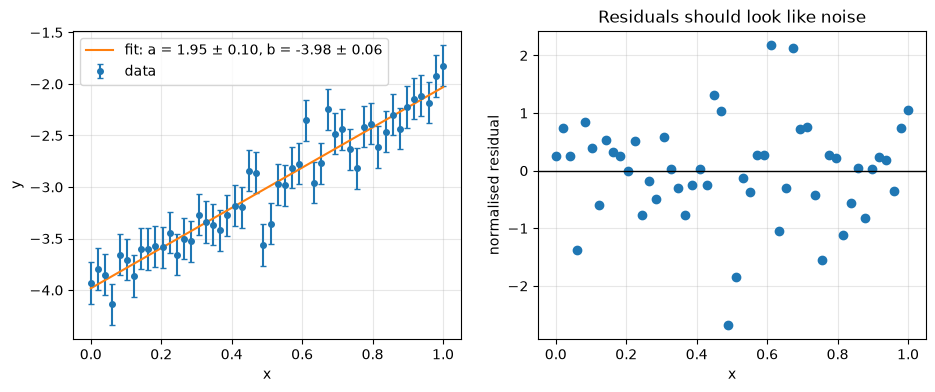

In [ ]:
resid = (y - line(x, *popt)) / sigma
chi2 = np.sum(resid**2)
nu = n - 2
print(f"χ² = {chi2:.1f},  ν = {nu},  reduced χ² = {chi2/nu:.2f},  p = {stats.chi2(nu).sf(chi2):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(x, y, yerr=sigma, fmt="o", ms=4, capsize=2, label="data")
ax[0].plot(x, line(x, *popt), "C1", label=f"fit: a = {popt[0]:.2f} ± {sa:.2f}, b = {popt[1]:.2f} ± {sb:.2f}")
ax[0].set(xlabel="x", ylabel="y"); ax[0].legend()
ax[1].plot(x, resid, "o"); ax[1].axhline(0, color="k", lw=1)
ax[1].set(xlabel="x", ylabel="normalised residual", title="Residuals should look like noise")
plt.show()

### When the errors are unknown

Often you have no independent estimate of $\sigma$. If you are prepared to *assume* the model is correct, the scatter of the residuals estimates the error:

$$
s^2 = \frac{1}{n - p}\sum_i \big(y_i - f(x_i; \hat{\boldsymbol{\theta}})\big)^2 .
$$

The parameter covariance is then $s^2 (\mathbf{A}^T\mathbf{A})^{-1}$. This is what `stats.linregress`, `np.polyfit(..., cov=True)` and `curve_fit` without `absolute_sigma` all do. The price is that you have given up the ability to test the model with $\chi^2$, since the reduced $\chi^2$ is 1 by construction; the residual plot is then your only check.

In [ ]:
lr = stats.linregress(x, y)
print(f"linregress, σ estimated from residuals:  a = {lr.slope:.3f} ± {lr.stderr:.3f}, b = {lr.intercept:.3f} ± {lr.intercept_stderr:.3f}")
print(f"curve_fit with known σ (absolute_sigma):  a = {popt[0]:.3f} ± {sa:.3f}, b = {popt[1]:.3f} ± {sb:.3f}")
s = np.sqrt(np.sum((y - line(x, *popt))**2) / (n - 2))
print(f"error estimated from the residuals: s = {s:.3f}   (true σ = {sigma})")

linregress, σ estimated from residuals:  a = 1.951 ± 0.086, b = -3.983 ± 0.050
curve_fit with known σ (absolute_sigma):  a = 1.951 ± 0.096, b = -3.983 ± 0.056
error estimated from the residuals: s = 0.179   (true σ = 0.2)


## Confidence regions and the $\Delta\chi^2$ rule

A standard error for each parameter separately does not tell the whole story when parameters are correlated. The **joint confidence region** for $(a, b)$ is the set of parameter values not rejected by the data, and it is most easily described through $\chi^2$. Write $\chi^2_{\min}$ for the value at the best fit. For normal errors the increase

$$
\Delta\chi^2(\boldsymbol{\theta}) = \chi^2(\boldsymbol{\theta}) - \chi^2_{\min}
$$

follows a chi-squared distribution with $p$ degrees of freedom, where $p$ is the number of parameters being varied. So the region $\Delta\chi^2 \le 2.30$ contains the true $(a, b)$ with probability 68% (the 0.68-quantile of $\chi^2_2$), and $\Delta\chi^2 \le 6.17$ with probability 95%. For a *single* parameter of interest, with any others re-optimised at each value (**profiling**), the thresholds are those of $\chi^2_1$: $\Delta\chi^2 \le 1$ gives a 68% interval, which is exactly $\pm$ one standard error.

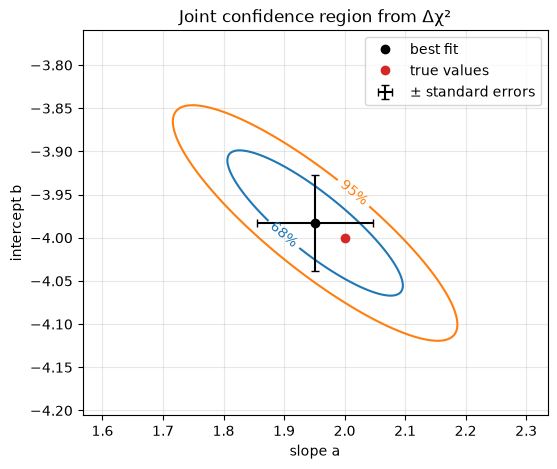

95% interval for a by profiling: [1.764, 2.139]
95% interval from a ± 1.96 sa:   [1.763, 2.140]


In [ ]:
aa = np.linspace(popt[0] - 4*sa, popt[0] + 4*sa, 200)
bb = np.linspace(popt[1] - 4*sb, popt[1] + 4*sb, 200)
A, B = np.meshgrid(aa, bb)
chi2_grid = np.sum(((y[:, None, None] - (A[None]*x[:, None, None] + B[None])) / sigma)**2, axis=0)
dchi2 = chi2_grid - chi2_grid.min()

levels = stats.chi2(2).ppf([0.68, 0.95])
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contour(A, B, dchi2, levels=levels, colors=["C0", "C1"])
ax.clabel(cs, fmt={levels[0]: "68%", levels[1]: "95%"})
ax.plot(popt[0], popt[1], "ko", label="best fit")
ax.plot(a_true, b_true, "C3o", label="true values")
ax.errorbar(popt[0], popt[1], xerr=sa, yerr=sb, fmt="none", color="k", capsize=3, label="± standard errors")
ax.set(xlabel="slope a", ylabel="intercept b", title="Joint confidence region from Δχ²"); ax.legend()
plt.show()

# 95% interval for the slope alone, by profiling over b
prof = dchi2.min(axis=0)                            # minimise over b for each a
inside = aa[prof <= stats.chi2(1).ppf(0.95)]
print(f"95% interval for a by profiling: [{inside.min():.3f}, {inside.max():.3f}]")
print(f"95% interval from a ± 1.96 sa:   [{popt[0] - 1.96*sa:.3f}, {popt[0] + 1.96*sa:.3f}]")

For a linear model with normal errors the $\Delta\chi^2$ region is an exact ellipse and profiling reproduces the $\pm 1.96\,s_a$ interval. The value of the $\Delta\chi^2$ approach is that it also works for nonlinear models, where the region need not be an ellipse and the covariance matrix is only an approximation. It is also the frequentist counterpart of the Bayesian posterior we meet in Notebook 7, which for flat priors is simply $\exp(-\chi^2/2)$.

## Real data: the rate of global warming

The repository contains NASA's GISTEMP series of annual global mean surface temperature anomalies relative to 1951–1980, from 1880 onwards. We fit a straight line to the data since 1970 to estimate the recent warming rate.

warming rate = 0.202 ± 0.009 °C per decade  (standard error from residual scatter)


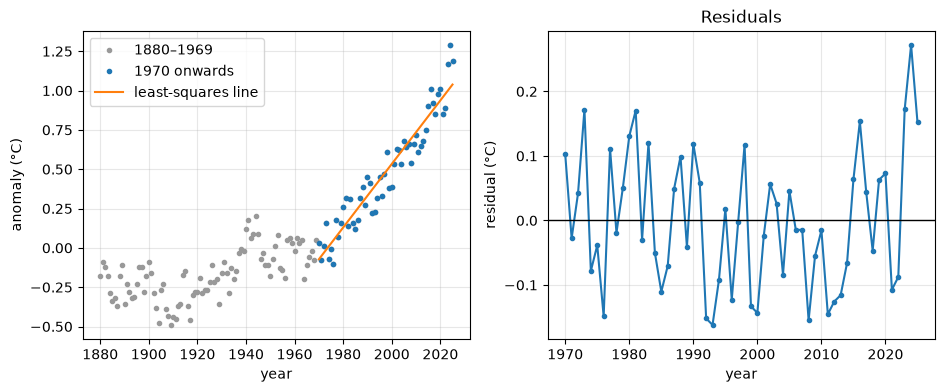

In [ ]:
gis = pd.read_csv(DATA + "gistemp_global_annual.csv")
recent = gis[gis["year"] >= 1970]
yr, T = recent["year"].to_numpy(dtype=float), recent["anomaly"].to_numpy()

lr = stats.linregress(yr, T)
print(f"warming rate = {10*lr.slope:.3f} ± {10*lr.stderr:.3f} °C per decade  (standard error from residual scatter)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(gis["year"], gis["anomaly"], ".", color="0.6", label="1880–1969")
ax[0].plot(yr, T, ".", label="1970 onwards")
ax[0].plot(yr, lr.intercept + lr.slope*yr, "C1", label="least-squares line")
ax[0].set(xlabel="year", ylabel="anomaly (°C)"); ax[0].legend()
r = T - (lr.intercept + lr.slope*yr)
ax[1].plot(yr, r, "o-", ms=3); ax[1].axhline(0, color="k", lw=1)
ax[1].set(xlabel="year", ylabel="residual (°C)", title="Residuals")
plt.show()

The rate is about 0.20 °C per decade with a formal standard error near 0.01 °C per decade. But look at the residuals: they wander, with runs of several consecutive years above or below the line (El Niño years are warm, volcanic years cool, and these influences persist). The residuals are **autocorrelated**, which violates the independence assumption behind the formulae. Autocorrelation does not bias the slope, but it makes the formal standard error too small, because $n$ consecutive correlated years carry less information than $n$ independent ones. Time-series methods correct for this; the point here is to recognise the symptom in the residual plot and not to over-trust the quoted uncertainty.

## Nonlinear models and model comparison: atmospheric CO₂

`curve_fit` handles any model. Here are the annual mean CO₂ concentrations at Mauna Loa, fitted with a straight line and with a quadratic. For nonlinear models you should always supply a starting guess `p0`; a poor guess can leave the optimiser stuck in a wrong local minimum. (A polynomial is linear in its parameters, so `p0` is not strictly needed here, but it is a good habit.)

linear    : parameters ['306.1', '1.672'],  residual standard deviation = 4.62 ppm
quadratic : parameters ['315.7', '0.7854', '0.01343'],  residual standard deviation = 0.76 ppm


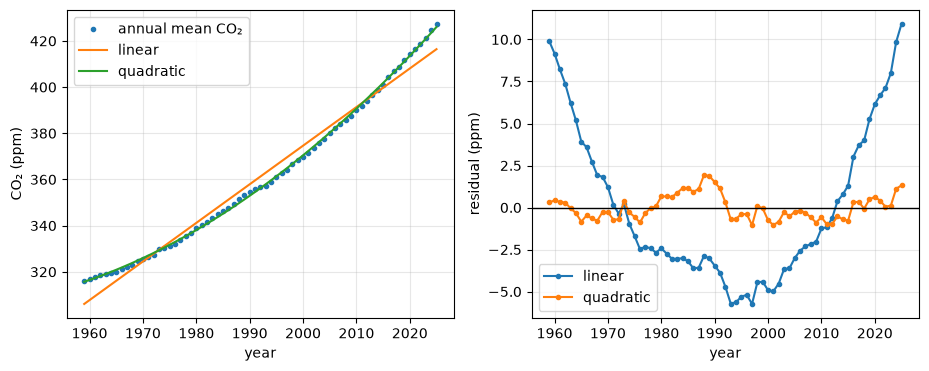

In [ ]:
co2 = pd.read_csv(DATA + "mauna_loa_co2_monthly.csv")
annual = co2.groupby("year")["co2"].mean()
annual = annual[(annual.index >= 1959) & (annual.index <= 2025)]      # complete years only
t = annual.index.to_numpy(dtype=float) - 1959
c = annual.to_numpy()

linear = lambda t, c0, c1: c0 + c1*t
quadratic = lambda t, c0, c1, c2: c0 + c1*t + c2*t**2

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t + 1959, c, "o", ms=3, label="annual mean CO₂")
for model, name, p0 in [(linear, "linear", [315, 1.5]), (quadratic, "quadratic", [315, 1.0, 0.01])]:
    popt, pcov = curve_fit(model, t, c, p0=p0)
    r = c - model(t, *popt)
    s = np.sqrt(np.sum(r**2) / (len(t) - len(popt)))
    print(f"{name:10s}: parameters {[f'{p:.4g}' for p in popt]},  residual standard deviation = {s:.2f} ppm")
    ax[0].plot(t + 1959, model(t, *popt), label=name)
    ax[1].plot(t + 1959, r, "o-", ms=3, label=name)
ax[0].set(xlabel="year", ylabel="CO₂ (ppm)"); ax[0].legend()
ax[1].axhline(0, color="k", lw=1); ax[1].set(xlabel="year", ylabel="residual (ppm)"); ax[1].legend()
plt.show()

The linear fit is hopeless: its residuals form a smooth curve, and the residual scatter of over 4 ppm is far larger than the measurement precision. The quadratic captures the accelerating rise, leaving residuals of a fraction of a ppm with a hint of remaining structure. The lesson is the same as before: residuals, not fitted values, tell you whether a model is adequate.

A word of caution about comparing models. Adding parameters *always* reduces $\chi^2$, so a lower residual is not by itself evidence for a more complex model; a fair comparison must account for the extra freedom. With known errors, the chi-squared test with $\nu = n - p$ does this. Without them, one can use an $F$-test for nested models, information criteria such as the AIC, or cross-validation (Notebook 8). And a good fit inside the range of the data says nothing about extrapolation beyond it: a quadratic fitted to 1959–2025 has no physical content and should not be used to predict 2100.

## Maximum likelihood beyond least squares: the Gutenberg–Richter $b$-value

The number of earthquakes above magnitude $M$ falls off as $N(\ge M) \propto 10^{-bM}$, the Gutenberg–Richter law, with $b$ close to 1 worldwide. Equivalently, above a completeness magnitude $M_c$ the quantity $M - M_c$ is exponentially distributed with rate $\beta = b \ln 10$. Estimating $b$ is not a least-squares problem: the natural approach is maximum likelihood for the exponential distribution, whose solution is the reciprocal of the sample mean (the Aki estimator):

$$
\hat{b} = \frac{\log_{10} e}{\bar{M} - M_c}, \qquad \sigma_{\hat b} \approx \frac{\hat b}{\sqrt{n}} .
$$

Magnitudes are reported to one decimal place, so the effective lower edge of the lowest bin is $M_c - 0.05$. We use `stats.expon.fit` with the location fixed at zero (`floc=0`) so that only the scale is fitted, and compare with the formula.

n = 17187,  b = 1.117 ± 0.009
check with the formula: 1.117


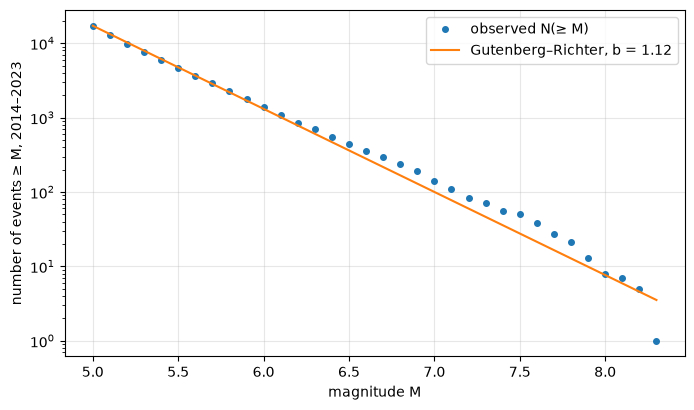

In [ ]:
quakes = pd.read_csv(DATA + "usgs_earthquakes_M5_2014_2023.csv")
M = quakes["mag"].to_numpy()
Mc = 5.0 - 0.05
loc, scale = stats.expon.fit(M - Mc, floc=0)
b_hat = np.log10(np.e) / scale
print(f"n = {len(M)},  b = {b_hat:.3f} ± {b_hat/np.sqrt(len(M)):.3f}")
print(f"check with the formula: {np.log10(np.e) / (M.mean() - Mc):.3f}")

# The classic plot: cumulative count against magnitude, log scale
mags = np.arange(5.0, 8.4, 0.1)
N = np.array([np.sum(M >= m - 1e-9) for m in mags])
fig, ax = plt.subplots()
ax.semilogy(mags, N, "o", ms=4, label="observed N(≥ M)")
ax.semilogy(mags, len(M) * 10**(-b_hat * (mags - 5.0)), "C1", label=f"Gutenberg–Richter, b = {b_hat:.2f}")
ax.set(xlabel="magnitude M", ylabel="number of events ≥ M, 2014–2023"); ax.legend()
plt.show()

The maximum likelihood line is fitted to the *individual magnitudes*, not to the plotted cumulative counts, and this matters: fitting a straight line by least squares to the log of the cumulative counts is common but wrong, because the points are not independent (each count includes all the ones to its right) and their errors are wildly unequal. Maximum likelihood with the correct distribution avoids both problems. This is a general principle: think about how the data were generated, write down the likelihood, and maximise it. Least squares is what results when the errors are normal, and only then.

## Summary

- Least squares is maximum likelihood for normal errors; weighted least squares minimises $\chi^2$.
- `curve_fit` fits any model and returns the parameter covariance matrix; use `absolute_sigma=True` when the errors are known.
- Judge fits by the residuals and by $\chi^2$ with $\nu = n - p$; a reduced $\chi^2$ near 1 with structureless residuals is what you want.
- Joint confidence regions come from $\Delta\chi^2$ thresholds; profiling gives intervals for one parameter at a time.
- Autocorrelated residuals mean the formal errors are too small; more parameters always fit better and need to be justified.
- When errors are not normal, write down the likelihood and maximise it directly.

## Exercises

### Exercise 1

Fit a straight line to the GISTEMP anomalies for 1880–1969 and compare the slope (in °C per decade, with its standard error) to the 1970-onwards value. Is the difference between the two rates statistically significant? Treat the two estimates as independent normal variables and use the propagation rule for a difference.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
early = gis[gis["year"] < 1970]
lr0 = stats.linregress(early["year"].astype(float), early["anomaly"])
lr1 = stats.linregress(yr, T)
d = lr1.slope - lr0.slope
sd = np.sqrt(lr1.stderr**2 + lr0.stderr**2)
print(f"1880–1969: {10*lr0.slope:.3f} ± {10*lr0.stderr:.3f} °C/decade")
print(f"1970–    : {10*lr1.slope:.3f} ± {10*lr1.stderr:.3f} °C/decade")
print(f"difference = {10*d:.3f} ± {10*sd:.3f} °C/decade,  z = {d/sd:.1f},  p = {2*stats.norm.sf(abs(d/sd)):.1e}")
```

The recent rate is more than five times the earlier one and the difference is many standard errors, so it is significant beyond any doubt even allowing for the autocorrelation that makes the formal errors optimistic.

</details>

### Exercise 2

Simulate data from an exponential decay $y = A e^{-t/\tau}$ with $A = 10$, $\tau = 2$, at $t = 0, 0.5, \dots, 10$, adding normal noise of standard deviation 0.3. Fit it with `curve_fit`, (a) with `p0=[10, 2]` and (b) with `p0=[1, 50]`. Report the fitted parameters and their standard errors, the reduced $\chi^2$, and the correlation between $A$ and $\tau$. What goes wrong in (b)?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
decay = lambda t, A, tau: A * np.exp(-t / tau)
t = np.arange(0, 10.01, 0.5)
yd = decay(t, 10, 2) + stats.norm(0, 0.3).rvs(len(t), random_state=rng)
for p0 in [[10, 2], [1, 50]]:
    try:
        popt, pcov = curve_fit(decay, t, yd, p0=p0, sigma=np.full(len(t), 0.3), absolute_sigma=True)
        se = np.sqrt(np.diag(pcov))
        chi2 = np.sum(((yd - decay(t, *popt)) / 0.3)**2)
        print(f"p0 = {p0}: A = {popt[0]:.2f} ± {se[0]:.2f}, τ = {popt[1]:.2f} ± {se[1]:.2f}, "
              f"reduced χ² = {chi2/(len(t)-2):.2f}, corr = {pcov[0,1]/(se[0]*se[1]):.2f}")
    except RuntimeError as e:
        print(f"p0 = {p0}: {e}")
```

From a sensible starting point the fit recovers $A \approx 10$ and $\tau \approx 2$ with a reduced $\chi^2$ near 1 and a modest positive correlation. From the poor starting point the optimiser may converge to a poor solution or fail with a "maximum number of function evaluations" error; a nonlinear fit only finds the nearest local minimum. Always plot the data with the fitted curve and check the reduced $\chi^2$.

</details>

### Exercise 3

*Errors in both variables.* When both $x$ and $y$ have errors, as in isochron dating, ordinary least squares is biased. The standard remedy is York's method, an iteratively reweighted least squares. The file `pearson_york.csv` contains a classic ten-point test data set with $\sigma_x$ and $\sigma_y$ for each point (used to test isochron software; the accepted answers are slope $-0.4805 \pm 0.0580$ and intercept $5.4799 \pm 0.2950$). Fit it (a) by ordinary least squares, (b) weighting by $\sigma_y$ only using `curve_fit`, and (c) with York's method. The solution provides an implementation of York's algorithm; use it to reproduce the accepted values.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
py = pd.read_csv(DATA + "pearson_york.csv")
X, Y, sx, sy = (py[k].to_numpy() for k in ["x", "y", "sigma_x", "sigma_y"])

def york(x, y, sx, sy, tol=1e-12, maxiter=200):
    # Straight-line fit with errors in both variables (York 1969; York et al. 2004).
    # Returns intercept a, slope b, and their standard errors.
    wx, wy = 1/sx**2, 1/sy**2
    b = np.polyfit(x, y, 1)[0]                     # starting slope
    for _ in range(maxiter):
        W = wx*wy / (wx + b**2*wy)
        xbar, ybar = np.sum(W*x)/np.sum(W), np.sum(W*y)/np.sum(W)
        U, V = x - xbar, y - ybar
        beta = W * (U/wy + b*V/wx)
        b_new = np.sum(W*beta*V) / np.sum(W*beta*U)
        if abs(b_new - b) < tol:
            b = b_new; break
        b = b_new
    a = ybar - b*xbar
    x_adj = xbar + beta
    u = x_adj - np.sum(W*x_adj)/np.sum(W)
    sb = np.sqrt(1/np.sum(W*u**2))
    sa = np.sqrt(1/np.sum(W) + (np.sum(W*x_adj)/np.sum(W))**2 * sb**2)
    return a, b, sa, sb

lr = stats.linregress(X, Y)
print(f"(a) ordinary least squares:  slope {lr.slope:.4f} ± {lr.stderr:.4f}, intercept {lr.intercept:.4f} ± {lr.intercept_stderr:.4f}")
popt, pcov = curve_fit(lambda x, a, b: a*x + b, X, Y, sigma=sy, absolute_sigma=True)
print(f"(b) weighted by σ_y only:    slope {popt[0]:.4f} ± {np.sqrt(pcov[0,0]):.4f}, intercept {popt[1]:.4f} ± {np.sqrt(pcov[1,1]):.4f}")
a, b, sa, sb = york(X, Y, sx, sy)
print(f"(c) York:                    slope {b:.4f} ± {sb:.4f}, intercept {a:.4f} ± {sa:.4f}")

fig, ax = plt.subplots()
ax.errorbar(X, Y, xerr=sx, yerr=sy, fmt="o", ms=4, capsize=2, label="data")
xx = np.linspace(-0.5, 8, 50)
ax.plot(xx, lr.intercept + lr.slope*xx, label="ordinary least squares")
ax.plot(xx, popt[1] + popt[0]*xx, label="weighted by σ_y")
ax.plot(xx, a + b*xx, label="York"); ax.set(xlabel="x", ylabel="y"); ax.legend(); plt.show()
```

The three answers differ substantially. Ordinary least squares ignores the fact that the precisely known points should dominate; weighting by $\sigma_y$ alone over-trusts the right-hand points, whose $x$ values are very uncertain; York's method balances both and reproduces the accepted slope of $-0.4805 \pm 0.0580$. (Isochron programs often multiply these errors by $\sqrt{\text{reduced }\chi^2}$ when the fit is poor, giving 0.071 here; that is the same residual-scaling idea as estimating $\sigma$ from the scatter.)

</details>